# Modelagem de Machine Learning — Dataset PCOS

**Treinar · Avaliar · Comparar · Explicar**

---

## 0. Setup — Imports

**Raciocínio:** descomente a linha abaixo se der erro no import.


In [96]:
# Se estiver no Colab e o import do shap falhar, descomente a linha abaixo:
#!pip install -q shap

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Divisão treino/teste e validação cruzada
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold

# Pré-processamento e pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Os 4 modelos de classificação que vamos comparar
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

# Métricas de avaliação
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             classification_report, confusion_matrix, ConfusionMatrixDisplay,
                             roc_curve, roc_auc_score)

# Configuração visual
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
RANDOM_STATE = 42  # fixa a aleatoriedade -> resultados reproduzíveis
print("✅ Bibliotecas importadas!")

✅ Bibliotecas importadas!


## 1. Carregar o Dataset Limpo

**Pergunta:** "O dataset está mesmo pronto para treinar?"

**Raciocínio:** revalidar as 3 garantias antes de modelar: (1) sem nulos, (2) tudo numérico,
(3) shape esperado. Custa 3 linhas e evita horas de dor de cabeça.


In [97]:
# Carrega o CSV limpo gerado pelo notebook de preparação
df = pd.read_csv("../datasets/pcos_clean.csv")

print(f"Shape: {df.shape}")
print(f"Total de nulos: {int(df.isna().sum().sum())}")
print(f"Colunas de texto (deveria ser 0): {list(df.select_dtypes(include='object').columns)}")
df.head(3)

Shape: (541, 42)
Total de nulos: 0
Colunas de texto (deveria ser 0): []


,PCOS (Y/N),Age (yrs),Weight (Kg),Height(Cm),BMI,Blood Group,Pulse rate(bpm),RR (breaths/min),Hb(g/dl),Cycle(R/I),...,Pimples(Y/N),Fast food (Y/N),Reg.Exercise(Y/N),BP _Systolic (mmHg),BP _Diastolic (mmHg),Follicle No. (L),Follicle No. (R),Avg. F size (L) (mm),Avg. F size (R) (mm),Endometrium (mm)
0,0,28,44.6,152.0,19.300000,15,78,22,10.48,2,...,0,1.0,0,110,80,3,3,18.0,18.0,8.5
1,0,36,65.0,161.5,24.921163,15,74,20,11.70,2,...,0,0.0,0,120,70,3,5,15.0,14.0,3.7
2,1,33,68.8,165.0,25.270891,11,72,18,11.80,2,...,1,1.0,0,120,80,13,15,18.0,20.0,10.0


**📊 Interpretação:** se nulos = 0, colunas de texto = 0 e shape = (541, 43), está tudo
certo.


## 2. Separar X/y e Fazer o Train/Test Split

### 2.1 Separar features (X) do alvo (y)

**Pergunta:** "O que o modelo recebe de entrada e o que ele deve prever?"

**Raciocínio:** o modelo aprende um mapeamento `X → y`. Aqui:
- **X** = todas as features (exames, sintomas, biometria) — o que o modelo "vê"
- **y** = `PCOS (Y/N)` — o que ele deve prever (0 = não tem, 1 = tem)


In [98]:
target = "PCOS (Y/N)"
X = df.drop(columns=[target])   # tudo, menos o alvo
y = df[target]                  # só o alvo

print(f"X (features): {X.shape[1]} colunas, {X.shape[0]} linhas")
print(f"y (alvo): {y.shape[0]} valores")
print(f"\nDistribuição do alvo:")
print(y.value_counts())
print(f"Proporção de positivos (PCOS=1): {y.mean()*100:.1f}%")

X (features): 41 colunas, 541 linhas
y (alvo): 541 valores

Distribuição do alvo:
PCOS (Y/N)
0    364
1    177
Name: count, dtype: int64
Proporção de positivos (PCOS=1): 32.7%


### 2.2 Dividir em Treino e Teste (com estratificação)

**Pergunta:** "Como avaliar o modelo de forma honesta?"

**Raciocínio:** se avaliarmos o modelo nos **mesmos** dados em que ele treinou, é como dar a
prova com o gabarito — ele "decora" em vez de "aprender". Por isso separamos:
- **Treino (80%):** o modelo aprende aqui
- **Teste (20%):** guardamos "escondido" para simular dados novos e medir o desempenho real

**Por que `stratify=y`?** Nosso alvo é desbalanceado (~33% positivos). Sem estratificação, o
sorteio poderia colocar, por azar, quase todos os positivos no treino e quase nenhum no teste.
`stratify=y` **garante a mesma proporção 67/33 nos dois conjuntos**.

**Por que `random_state=42`?** Fixa o sorteio aleatório — assim você (e o avaliador) obtêm
sempre o mesmo split. Reprodutibilidade é requisito de trabalho científico.


In [99]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,          # 20% para teste
    stratify=y,             # mantém a proporção de classes nos dois lados
    random_state=RANDOM_STATE
)

print(f"Treino: {X_train.shape[0]} amostras | Teste: {X_test.shape[0]} amostras\n")

# PROVA de que o stratify funcionou: proporções quase idênticas
comp = pd.DataFrame({
    "Treino (%)": y_train.value_counts(normalize=True).mul(100).round(1),
    "Teste (%)":  y_test.value_counts(normalize=True).mul(100).round(1),
})
print("Proporção da classe em cada conjunto (devem ser parecidas):")
print(comp)

Treino: 432 amostras | Teste: 109 amostras

Proporção da classe em cada conjunto (devem ser parecidas):
            Treino (%)  Teste (%)
PCOS (Y/N)                       
0                 67.4       67.0
1                 32.6       33.0


**Interpretação:** as colunas Treino(%) e Teste(%) estão praticamente iguais (~67% / ~33%).
Isso confirma que o `stratify` preservou o balanceamento. Se estivessem muito diferentes, a
avaliação seria enviesada.


## 3. Estratégia de Modelagem — Quais Modelos e Por Quê

**Pergunta:** "Quais algoritmos testar?"

**Raciocínio:** Testar **4** para ter uma comparação rica. Escolhendo algoritmos com "filosofias" diferentes:

| Modelo | Como pensa | Precisa escalar? |
|---|---|---|
| **KNN** | "quem são meus vizinhos mais próximos?" (distância) | ✅ Sim |
| **Árvore de Decisão** | "faço perguntas sim/não em cascata" (limiares) | ❌ Não |
| **Random Forest** | "junto o voto de várias árvores" (ensemble) | ❌ Não |
| **Regressão Logística** | "traço uma fronteira linear" (probabilidade) | ✅ Sim |

**Decisão de projeto:** envolvendo TODOS num **Pipeline** com `StandardScaler`. Os que
precisam de escala se beneficiam; os que não precisam (árvores) não são prejudicados. Assim
padroniza o código e — o mais importante — **o scaler aprende só no treino**, evitando o
data leakage.

> **Reforço do conceito:** o `pcos_clean.csv` está SEM escalar (valores reais). O
> escalonamento acontece AQUI, dentro do pipeline, na hora do treino. É o lugar certo.


In [100]:
# Dicionário com os 4 modelos. Cada um vira um pipeline (scaler + modelo).
modelos = {
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Árvore de Decisão": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(random_state=RANDOM_STATE),
    "Regressão Logística": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
}

def criar_pipeline(modelo):
    """Envolve qualquer modelo num pipeline com escalonamento.
    O StandardScaler faz fit() SÓ com os dados de treino (dentro do .fit do pipeline),
    aplicando transform() em treino e teste -> sem vazamento de dados."""
    return Pipeline([
        ("scaler", StandardScaler()),
        ("model", modelo),
    ])

print("Modelos que vamos comparar:")
for nome in modelos:
    print(f"  • {nome}")

Modelos que vamos comparar:
  • KNN
  • Árvore de Decisão
  • Random Forest
  • Regressão Logística


## 4. Baseline — Um Primeiro Modelo Simples

**Pergunta:** "Qual o desempenho 'de fábrica', sem otimizar nada?"

**Raciocínio:** antes de comparar tudo, treinamos **um** modelo simples para ter uma
**referência (baseline)**. Se depois um modelo sofisticado não superar essa baseline, algo
está errado. Vamos usar a **Árvore de Decisão** — ela é interpretável e boa para começar.


In [101]:
# Cria e treina o pipeline da árvore
pipe_baseline = criar_pipeline(DecisionTreeClassifier(random_state=RANDOM_STATE))
pipe_baseline.fit(X_train, y_train)      # aprende com o treino

# Prediz no teste (dados que o modelo NUNCA viu)
y_pred_base = pipe_baseline.predict(X_test)

# Relatório completo por classe
print("Relatório de classificação — Baseline (Árvore de Decisão):\n")
print(classification_report(y_test, y_pred_base, target_names=["Não PCOS (0)", "PCOS (1)"]))

Relatório de classificação — Baseline (Árvore de Decisão):

              precision    recall  f1-score   support

Não PCOS (0)       0.91      0.93      0.92        73
    PCOS (1)       0.85      0.81      0.83        36

    accuracy                           0.89       109
   macro avg       0.88      0.87      0.87       109
weighted avg       0.89      0.89      0.89       109



**Como ler o `classification_report`:**

- **precision (precisão):** dos que o modelo disse "tem PCOS", quantos realmente têm? (evita falso alarme)
- **recall (sensibilidade):** dos que realmente têm PCOS, quantos o modelo achou? (evita diagnóstico perdido)
- **f1-score:** média harmônica entre precision e recall (equilíbrio)
- **support:** quantas amostras reais de cada classe existem no teste

**No contexto médico**, olhe com atenção o **recall da classe "PCOS (1)"**: é a taxa de
pacientes doentes que o modelo consegue identificar. Um recall baixo significa que estamos
**deixando passar** casos reais — o erro mais perigoso em diagnóstico.


### 4.1 Entendendo os erros: por que Recall é crítico aqui?

**Raciocínio:** em diagnóstico, nem todo erro custa o mesmo:

| Tipo de erro | O que significa | Gravidade |
|---|---|---|
| **Falso Negativo (FN)** | Paciente TEM PCOS, modelo disse que NÃO | **GRAVE** — diagnóstico perdido, sem tratamento |
| **Falso Positivo (FP)** | Paciente NÃO tem, modelo disse que SIM | Menos grave — exames extras confirmam |

Por isso, entre dois modelos com acurácia parecida, **preferimos o que tem menos Falsos
Negativos** (ou seja, maior Recall na classe positiva).


## 5. Treinar Todos os Modelos

**Pergunta:** "Como comparar os 4 modelos de forma justa?"

**Raciocínio:** treino justo = **mesmos dados, mesmo pré-processamento, mesmas métricas**.
Fazemos um loop: para cada modelo, criamos o pipeline, treinamos no treino, prevemos no teste
e guardamos as métricas num dicionário. Assim ninguém leva vantagem indevida.


In [102]:
resultados = {}   # vai guardar métricas e o pipeline treinado de cada modelo

for nome, modelo in modelos.items():
    pipe = criar_pipeline(modelo)
    pipe.fit(X_train, y_train)                 # treina
    y_pred = pipe.predict(X_test)              # prevê no teste

    # Probabilidade da classe positiva (para a curva ROC depois)
    y_proba = pipe.predict_proba(X_test)[:, 1]

    resultados[nome] = {
        "Accuracy":  accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall":    recall_score(y_test, y_pred),
        "F1":        f1_score(y_test, y_pred),
        "AUC":       roc_auc_score(y_test, y_proba),
        "_pipe":     pipe,          # guardamos o pipeline treinado
        "_proba":    y_proba,       # e as probabilidades
        "_pred":     y_pred,        # e as predições
    }
    print(f"✅ {nome} treinado.")

print("\nTodos os modelos foram treinados e avaliados!")

✅ KNN treinado.


✅ Árvore de Decisão treinado.
✅ Random Forest treinado.
✅ Regressão Logística treinado.

Todos os modelos foram treinados e avaliados!


## 6. Comparar os Modelos — Tabela e Gráfico

**Pergunta:** "Qual modelo é o melhor?"

**Raciocínio:** montamos uma tabela com todas as métricas lado a lado. **Ordenamos por
Recall** (nossa métrica prioritária no contexto médico), usando o F1 como critério de desempate.


In [103]:
# Monta a tabela de comparação (só as métricas, sem os objetos internos "_")
metricas = ["Accuracy", "Precision", "Recall", "F1", "AUC"]
tabela = pd.DataFrame(
    {nome: {m: resultados[nome][m] for m in metricas} for nome in resultados}
).T

# Ordena por Recall (desc) e depois F1 (desc)
tabela = tabela.sort_values(["Recall", "F1"], ascending=False).round(3)
print("Ranking dos modelos (ordenado por Recall, depois F1):\n")
tabela

Ranking dos modelos (ordenado por Recall, depois F1):



,Accuracy,Precision,Recall,F1,AUC
Regressão Logística,0.890,0.816,0.861,0.838,0.951
Árvore de Decisão,0.890,0.853,0.806,0.829,0.869
Random Forest,0.899,0.903,0.778,0.836,0.948
KNN,0.899,0.963,0.722,0.825,0.937


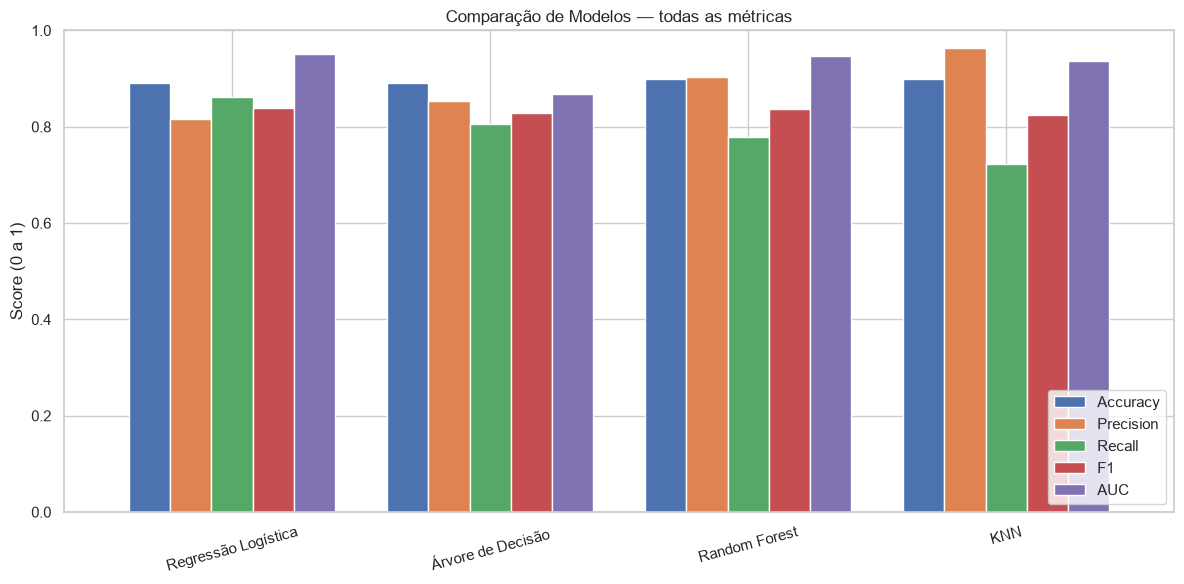

In [104]:
# Gráfico de barras agrupadas: compara as métricas visualmente
ax = tabela[metricas].plot(kind="bar", figsize=(12, 6), width=0.8)
ax.set_title("Comparação de Modelos — todas as métricas")
ax.set_ylabel("Score (0 a 1)")
ax.set_xlabel("")
ax.set_ylim(0, 1)
ax.legend(loc="lower right")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

In [105]:
# Identifica o melhor modelo pelo Recall (nosso critério) de forma automática
melhor_nome = tabela.index[0]
print(f"Modelo campeão (maior Recall): {melhor_nome}")
print(f"Recall = {tabela.loc[melhor_nome, 'Recall']:.3f} | "
      f"F1 = {tabela.loc[melhor_nome, 'F1']:.3f} | "
      f"AUC = {tabela.loc[melhor_nome, 'AUC']:.3f}")

Modelo campeão (maior Recall): Regressão Logística
Recall = 0.861 | F1 = 0.838 | AUC = 0.951


**Interpretação:**

- **Não escolha o modelo só pela Accuracy!** Com 67% de negativos, um modelo "preguiçoso"
  que sempre chuta "não tem PCOS" já acerta 67% — mas tem Recall zero na classe positiva
  (não acha nenhum doente). Inútil na prática.
- Por isso priorizamos **Recall** e **F1** na classe positiva.
- O **AUC** complementa: mede a capacidade de separar as duas classes em qualquer limiar.

> O modelo campeão foi escolhido **automaticamente** pela célula acima (`melhor_nome`).


## 7. Matriz de Confusão — Onde Cada Modelo Erra

**Pergunta:** "ONDE exatamente os modelos acertam e erram?"

**Raciocínio:** a matriz de confusão abre os acertos/erros em 4 quadrantes. É aqui que
enxergamos os **Falsos Negativos** (o erro grave). Plotando as 4 matrizes juntas.


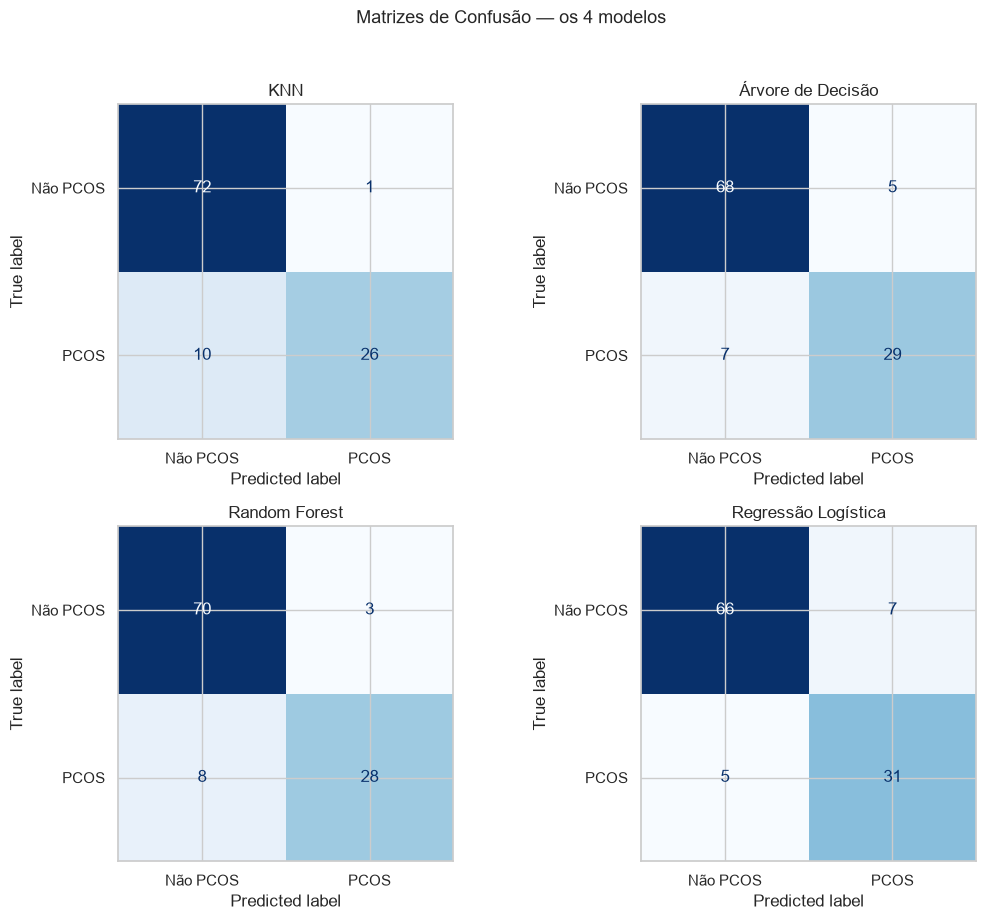

In [106]:
fig, axes = plt.subplots(2, 2, figsize=(11, 9))
axes = axes.ravel()

for ax, nome in zip(axes, resultados):
    cm = confusion_matrix(y_test, resultados[nome]["_pred"])
    disp = ConfusionMatrixDisplay(cm, display_labels=["Não PCOS", "PCOS"])
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(nome)

plt.suptitle("Matrizes de Confusão — os 4 modelos", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

**Como ler cada matriz (formato 2×2):**

```
                    Previsto: Não    Previsto: Sim
Real: Não PCOS          TN               FP          ← FP = falso alarme (ok)
Real: PCOS              FN               TP          ← FN = diagnóstico perdido (GRAVE)
```

- **Canto superior esquerdo (TN):** acertou os saudáveis
- **Canto inferior direito (TP):** acertou os doentes
- **Inferior esquerdo (FN):** disse "não tem" mas TINHA → o número que queremos MINIMIZAR
- **Superior direito (FP):** disse "tem" mas não tinha → tolerável

**Decisão prática:** entre modelos parecidos, escolha o que tem o **menor FN** (canto
inferior esquerdo). É o mais seguro para triagem médica.


## 8. Curva ROC e AUC

**Pergunta:** "Quão bem cada modelo separa as duas classes?"

**Raciocínio:** o modelo dá uma **probabilidade** de PCOS, e nós escolhemos um limiar (padrão
0.5) para decidir. A curva ROC mostra o trade-off entre acertar positivos (TPR/Recall) e dar
falsos alarmes (FPR) em **todos** os limiares. Quanto mais a curva "abraça" o canto superior
esquerdo, melhor. O **AUC** resume isso num número (1.0 = perfeito, 0.5 = chute aleatório).


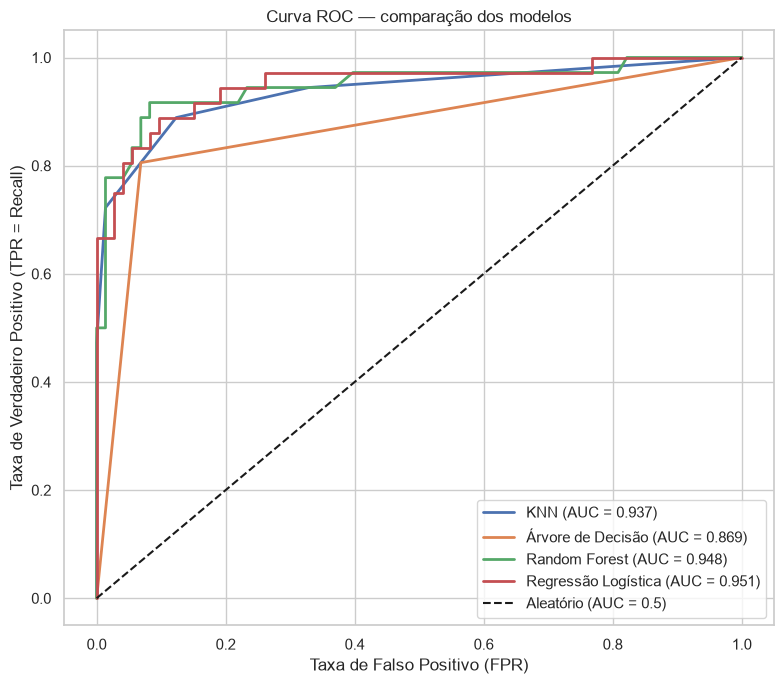

In [107]:
plt.figure(figsize=(8, 7))

for nome in resultados:
    fpr, tpr, _ = roc_curve(y_test, resultados[nome]["_proba"])
    auc = resultados[nome]["AUC"]
    plt.plot(fpr, tpr, label=f"{nome} (AUC = {auc:.3f})", linewidth=2)

# Linha diagonal = chute aleatório (referência)
plt.plot([0, 1], [0, 1], "k--", label="Aleatório (AUC = 0.5)")
plt.xlabel("Taxa de Falso Positivo (FPR)")
plt.ylabel("Taxa de Verdadeiro Positivo (TPR = Recall)")
plt.title("Curva ROC — comparação dos modelos")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

**Interpretação:**
- Curva mais **alta e à esquerda** = melhor separação entre doentes e saudáveis.
- **AUC > 0.9** = excelente; **0.8–0.9** = bom; **0.7–0.8** = razoável; **~0.5** = inútil.
- A linha tracejada é o "chute de moeda" — qualquer modelo útil deve ficar **acima** dela.


## 9. Tuning de Hiperparâmetros

**Pergunta:** "Consigo melhorar o modelo ajustando seus parâmetros?"

**Raciocínio:** cada modelo tem "botões" (hiperparâmetros) que mudam seu comportamento —
ex: número de árvores, profundidade máxima. Testar combinações na mão é inviável. O
`GridSearchCV` testa **todas as combinações** de uma grade, usando **validação cruzada**
(divide o treino em k partes, treina em k-1 e valida na restante, k vezes) para não depender
de um único split de sorte.

**Detalhe crucial:** otimizamos por `scoring="recall"` — pedimos ao Grid para buscar os
parâmetros que **maximizam o Recall** (achar doentes), não a acurácia. A métrica de
otimização deve refletir o objetivo do problema.

Vamos tunar a **Random Forest** (costuma ser forte neste tipo de dado).


In [108]:
# Pipeline base da Random Forest
pipe_rf = criar_pipeline(RandomForestClassifier(random_state=RANDOM_STATE))

# Grade de hiperparâmetros. Note o prefixo "model__" (nome do passo no pipeline).
param_grid = {
    "model__n_estimators": [100, 200],       # nº de árvores
    "model__max_depth": [None, 5, 10],        # profundidade máxima
    "model__min_samples_split": [2, 5],       # mín. de amostras para dividir um nó
}

# Validação cruzada estratificada (mantém proporção de classes em cada fold)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

grid = GridSearchCV(
    pipe_rf, param_grid,
    scoring="recall",     # otimiza RECALL (nosso objetivo)
    cv=cv,
    n_jobs=1,            # usa todos os núcleos disponíveis com o -1 - paralelismo
)
grid.fit(X_train, y_train)

print("Melhores hiperparâmetros encontrados:")
for k, v in grid.best_params_.items():
    print(f"   {k} = {v}")
print(f"\nMelhor Recall na validação cruzada: {grid.best_score_:.3f}")

Melhores hiperparâmetros encontrados:
   model__max_depth = 10
   model__min_samples_split = 2
   model__n_estimators = 200

Melhor Recall na validação cruzada: 0.781


In [109]:
# Avalia o modelo TUNADO no conjunto de teste e compara com a RF default
modelo_tunado = grid.best_estimator_
y_pred_tunado = modelo_tunado.predict(X_test)

print("Random Forest TUNADA — desempenho no teste:\n")
print(classification_report(y_test, y_pred_tunado, target_names=["Não PCOS (0)", "PCOS (1)"]))

# Comparação direta (default vs tunada) no Recall e F1
rf_default = resultados["Random Forest"]
print("Comparação (classe PCOS=1):")
print(f"  RF default -> Recall: {rf_default['Recall']:.3f} | F1: {rf_default['F1']:.3f}")
print(f"  RF tunada  -> Recall: {recall_score(y_test, y_pred_tunado):.3f} | "
      f"F1: {f1_score(y_test, y_pred_tunado):.3f}")

Random Forest TUNADA — desempenho no teste:

              precision    recall  f1-score   support

Não PCOS (0)       0.90      0.97      0.93        73
    PCOS (1)       0.93      0.78      0.85        36

    accuracy                           0.91       109
   macro avg       0.92      0.88      0.89       109
weighted avg       0.91      0.91      0.91       109

Comparação (classe PCOS=1):
  RF default -> Recall: 0.778 | F1: 0.836
  RF tunada  -> Recall: 0.778 | F1: 0.848


**Interpretação:** compare o Recall antes/depois do tuning. Nem sempre o tuning melhora
muito (às vezes o default já é bom) — e **tudo bem**. O importante é ter feito a busca de forma
metodológica e otimizando a métrica certa. Se a versão tunada for melhor ou igual, usamos ela
daqui pra frente.


### 9.2 Tuning do Segundo Modelo — Regressão Logística

**Pergunta:** "E se otimizarmos a Regressão Logística, que foi a campeã no Recall?"

**Raciocínio:** o desafio pede **pelo menos 2 modelos** de classificação. Já comparamos 4,
mas só tunamos a Random Forest. Para mostrar domínio completo do processo, vamos otimizar
também a **Regressão Logística** — ela teve o melhor Recall "de fábrica" (0.861).

A Regressão Logística tem hiperparâmetros diferentes de árvores. Os principais:
- **`C`:** inverso da regularização (menor C = mais regularização, menos overfitting)
- **`penalty`:** tipo de regularização (L1 remove features, L2 encolhe coeficientes)
- **`solver`:** algoritmo de otimização


In [110]:
# Pipeline base da Regressão Logística
pipe_lr = criar_pipeline(LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))

# Grade de hiperparâmetros
param_grid_lr = {
    "model__C": [0.01, 0.1, 1, 10, 100],           # força de regularização
    "model__penalty": ["l2"],                      # L2 é padrão (L1 precisa solver compatível)
    "model__solver": ["lbfgs", "liblinear"],       # algoritmos de otimização
}

# Mesma estratégia: validação cruzada estratificada, otimizando Recall
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

grid_lr = GridSearchCV(
    pipe_lr, param_grid_lr,
    scoring="recall",     # mesma métrica de otimização
    cv=cv,
    n_jobs=1,
)
grid_lr.fit(X_train, y_train)

print("Melhores hiperparâmetros — Regressão Logística:")
for k, v in grid_lr.best_params_.items():
    print(f"   {k} = {v}")
print(f"\nMelhor Recall na validação cruzada: {grid_lr.best_score_:.3f}")

Melhores hiperparâmetros — Regressão Logística:
   model__C = 0.01
   model__penalty = l2
   model__solver = liblinear

Melhor Recall na validação cruzada: 0.837


In [111]:
# Avalia a Regressão Logística TUNADA no teste
modelo_lr_tunado = grid_lr.best_estimator_
y_pred_lr_tunado = modelo_lr_tunado.predict(X_test)

print("Regressão Logística TUNADA — desempenho no teste:\n")
print(classification_report(y_test, y_pred_lr_tunado, target_names=["Não PCOS (0)", "PCOS (1)"]))

# Comparação direta (default vs tunada)
lr_default = resultados["Regressão Logística"]
print("Comparação (classe PCOS=1):")
print(f"  RegLog default -> Recall: {lr_default['Recall']:.3f} | F1: {lr_default['F1']:.3f}")
print(f"  RegLog tunada  -> Recall: {recall_score(y_test, y_pred_lr_tunado):.3f} | "
      f"F1: {f1_score(y_test, y_pred_lr_tunado):.3f}")

Regressão Logística TUNADA — desempenho no teste:

              precision    recall  f1-score   support

Não PCOS (0)       0.96      0.92      0.94        73
    PCOS (1)       0.85      0.92      0.88        36

    accuracy                           0.92       109
   macro avg       0.90      0.92      0.91       109
weighted avg       0.92      0.92      0.92       109

Comparação (classe PCOS=1):
  RegLog default -> Recall: 0.861 | F1: 0.838
  RegLog tunada  -> Recall: 0.917 | F1: 0.880


**Interpretação:** compare as duas versões tunadas (RF vs RegLog) e com os defaults.
Nem sempre o tuning melhora muito — às vezes o default já é bom. O importante é ter feito a
busca metodológica em **2+ modelos diferentes** (requisito do desafio).


### 9.3 Comparação Final — Dois Modelos Tunados

**Pergunta:** "Qual dos dois modelos tunados usar como FINAL?"

**Raciocínio:** agora temos Random Forest tunada e Regressão Logística tunada. Vamos compará-las
lado a lado para escolher o **modelo final** (que será salvo na Seção 12).


In [112]:
# Cria tabela comparativa dos dois tunados
comparacao_tunados = pd.DataFrame({
    "Random Forest (tunada)": {
        "Accuracy":  accuracy_score(y_test, y_pred_tunado),
        "Precision": precision_score(y_test, y_pred_tunado),
        "Recall":    recall_score(y_test, y_pred_tunado),
        "F1":        f1_score(y_test, y_pred_tunado),
    },
    "Reg. Logística (tunada)": {
        "Accuracy":  accuracy_score(y_test, y_pred_lr_tunado),
        "Precision": precision_score(y_test, y_pred_lr_tunado),
        "Recall":    recall_score(y_test, y_pred_lr_tunado),
        "F1":        f1_score(y_test, y_pred_lr_tunado),
    }
}).T

print("Comparação dos 2 modelos tunados (ordenado por Recall):\n")
comparacao_tunados = comparacao_tunados.sort_values("Recall", ascending=False).round(3)
print(comparacao_tunados)

# Escolhe o vencedor final baseado no Recall
modelo_final_nome = comparacao_tunados.index[0]
if "Random Forest" in modelo_final_nome:
    modelo_final = modelo_tunado
    y_pred_final = y_pred_tunado
else:
    modelo_final = modelo_lr_tunado
    y_pred_final = y_pred_lr_tunado

print(f"\nModelo FINAL escolhido: {modelo_final_nome}")
print(f"   (será salvo na Seção 12 e usado para SHAP na Seção 11)")

Comparação dos 2 modelos tunados (ordenado por Recall):

                         Accuracy  Precision  Recall     F1
Reg. Logística (tunada)     0.917      0.846   0.917  0.880
Random Forest (tunada)      0.908      0.933   0.778  0.848

Modelo FINAL escolhido: Reg. Logística (tunada)
   (será salvo na Seção 12 e usado para SHAP na Seção 11)


**Decisão:** o modelo com **maior Recall** entre os dois tunados é o escolhido como final.
Ele minimiza Falsos Negativos (diagnósticos perdidos), que é o erro crítico em medicina.

> A variável `modelo_final` agora aponta para o vencedor.

## 10. Explicabilidade I — Feature Importance

**Pergunta:** "QUAIS variáveis o modelo mais usa para decidir?"

**Raciocínio:** um modelo médico não pode ser uma "caixa-preta". Precisamos saber no que ele
se baseia — tanto para **confiar** nele quanto para **validar clinicamente**. Modelos baseados
em árvore (como a Random Forest) expõem `feature_importances_`: o quanto cada variável ajudou a
reduzir a incerteza nas divisões das árvores.


C:\Users\fabar\AppData\Local\Temp\ipykernel_14084\3106370832.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top15.values, y=top15.index, palette="viridis")


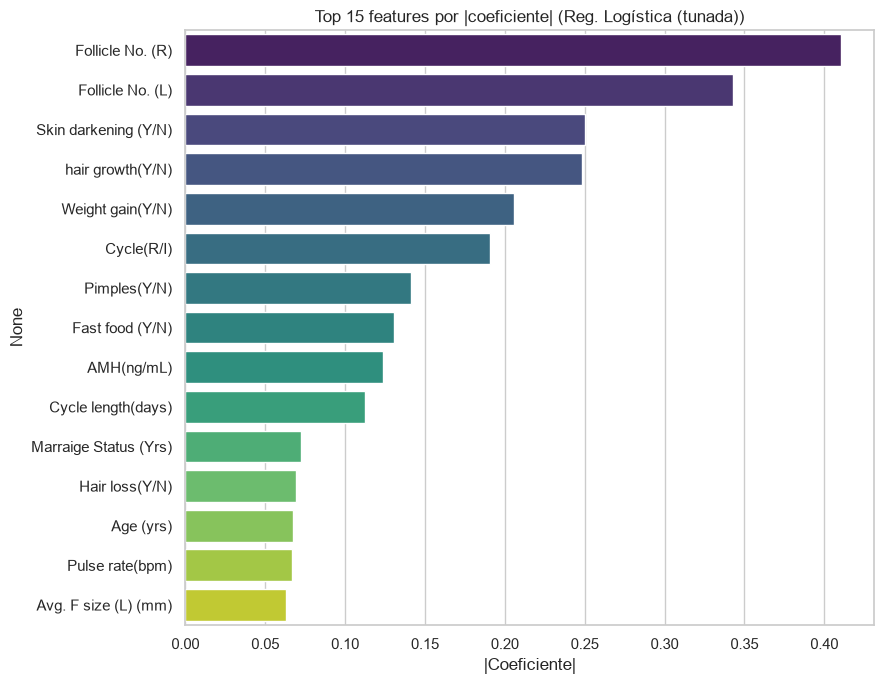

Top 5 features:
  Follicle No. (R): 0.411
  Follicle No. (L): 0.343
  Skin darkening (Y/N): 0.250
  hair growth(Y/N): 0.248
  Weight gain(Y/N): 0.205


In [113]:
# Usa o modelo final escolhido (Random Forest ou Reg. Log. tunada).
modelo_final_step = modelo_final.named_steps["model"]

# IMPORTANTE: nem todo modelo tem feature_importances_!
# - Árvores (RF, DT) → .feature_importances_
# - Regressão Logística → .coef_ (coeficientes absolutos)
if hasattr(modelo_final_step, "feature_importances_"):
    # Modelo baseado em árvore
    importancias = pd.Series(modelo_final_step.feature_importances_, index=X.columns)
    titulo = f"Top 15 features mais importantes ({modelo_final_nome})"
else:
    # Modelo linear (Regressão Logística)
    # Pegamos o valor absoluto dos coeficientes (quanto maior, mais influente)
    importancias = pd.Series(np.abs(modelo_final_step.coef_[0]), index=X.columns)
    titulo = f"Top 15 features por |coeficiente| ({modelo_final_nome})"

top15 = importancias.sort_values(ascending=False).head(15)

plt.figure(figsize=(9, 7))
sns.barplot(x=top15.values, y=top15.index, palette="viridis")
plt.title(titulo)
plt.xlabel("Importância relativa" if hasattr(modelo_final_step, "feature_importances_") else "|Coeficiente|")
plt.tight_layout()
plt.show()

print("Top 5 features:")
for feat, imp in top15.head(5).items():
    print(f"  {feat}: {imp:.3f}")

**Interpretação clínica:** verifique se as features do topo fazem **sentido médico** para
PCOS. É esperado ver coisas como:
- **Follicle No. (L/R):** contagem de folículos — critério ecográfico clássico de SOP
- **AMH:** hormônio anti-mülleriano, tipicamente elevado em PCOS
- **FSH/LH:** a razão hormonal alterada é marcador conhecido
- **Weight gain / hair growth / Skin darkening:** sintomas típicos

> **Diferença entre modelos:**
> - **Árvores (RF/DT):** feature_importances_ = redução de impureza (Gini/entropia)
> - **Regressão Logística:** coeficientes = peso de cada feature na fronteira de decisão
>
> Se as features importantes batem com o conhecimento médico, isso é um forte sinal de que o
> modelo aprendeu padrões **reais** — não ruído. Se aparecesse algo sem sentido no topo (ex: um
> ID), seria um alerta de vazamento ou erro na preparação.


## 11. Explicabilidade II — SHAP

**Pergunta:** "COMO o modelo decide caso a caso? Cada feature empurra para 'tem' ou 'não tem'?"

**Raciocínio:** o Feature Importance (Seção 10) dá uma visão **global** ("no geral, o que
importa"), mas não diz a **direção** nem explica **decisões individuais**. O **SHAP** faz isso:
para cada paciente, mede quanto cada feature empurrou a predição para cima (PCOS) ou para baixo
(não-PCOS). É a técnica de explicabilidade mais respeitada hoje e é requisito do desafio.


In [114]:
import shap

# Escolhe o explainer correto conforme o tipo de modelo
# TreeExplainer → modelos de árvore (RF, DT, XGBoost, etc.)
# LinearExplainer → modelos lineares (Regressão Logística, SVM linear)
# KernelExplainer → agnóstico, mas mais lento (fallback universal)

if hasattr(modelo_final_step, "feature_importances_"):
    # Modelo baseado em árvore
    explainer = shap.TreeExplainer(modelo_final_step)
    X_explain = X_test   # TreeExplainer trabalha com os dados originais
    print("Usando TreeExplainer (modelo de árvore)")
else:
    # Modelo linear (Regressão Logística)
    # LinearExplainer precisa dos dados ESCALONADOS (o scaler está no pipeline)
    scaler = modelo_final.named_steps["scaler"]
    X_explain = pd.DataFrame(scaler.transform(X_test), columns=X.columns, index=X_test.index)
    explainer = shap.LinearExplainer(modelo_final_step, X_explain)
    print("Usando LinearExplainer (modelo linear)")

shap_values = explainer.shap_values(X_explain)

# Compatibilidade entre versões do SHAP: normalizamos para pegar a classe positiva (PCOS=1).
if isinstance(shap_values, list):
    shap_pcos = shap_values[1]                 # classe 1
elif hasattr(shap_values, "ndim") and shap_values.ndim == 3:
    shap_pcos = shap_values[:, :, 1]           # array 3D -> classe 1
else:
    shap_pcos = shap_values                    # já é 2D

print("✅ SHAP values calculados. Formato:", np.array(shap_pcos).shape)

Background dataset has 109 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=109 when initializing the masker.


Usando LinearExplainer (modelo linear)
✅ SHAP values calculados. Formato: (109, 41)


### 11.1 Summary Plot — visão global com direção

**Raciocínio:** este gráfico mostra, para cada feature, como seus valores afetam a predição.
Cada ponto é um paciente.


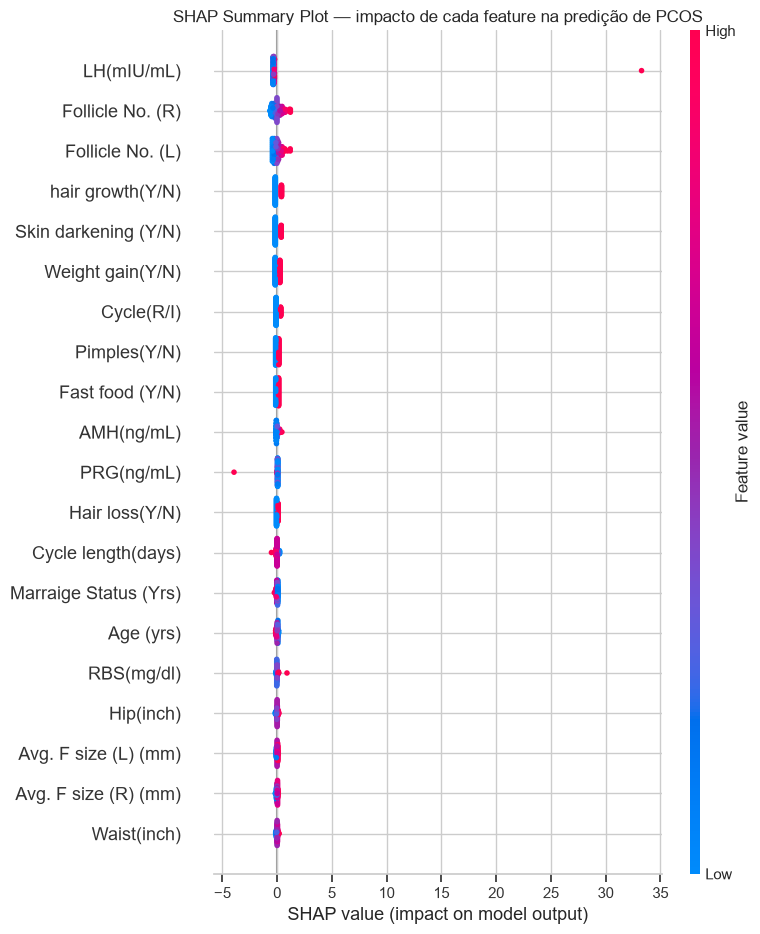

In [115]:
shap.summary_plot(shap_pcos, X_explain, show=False)
plt.title("SHAP Summary Plot — impacto de cada feature na predição de PCOS")
plt.tight_layout()
plt.show()

**Como ler o Summary Plot:**
- **Eixo Y:** features ordenadas por importância (topo = mais influente)
- **Eixo X (SHAP value):** à direita = empurra para **PCOS=Sim**; à esquerda = para **Não**
- **Cor:** 🔴 vermelho = valor ALTO da feature; 🔵 azul = valor BAIXO

**Exemplo de leitura:** se em "Follicle No. (R)" os pontos vermelhos (muitos folículos) estão à
direita, significa que **muitos folículos empurram a predição para PCOS** — exatamente o
esperado clinicamente. ✅


### 11.2 Force Plot — explicando UMA paciente

**Raciocínio:** e para um caso específico? O force plot mostra quais features "puxaram" a
decisão daquele paciente. Ótimo para explicar ao médico *por que* o modelo sinalizou aquela
paciente.


Explicando o paciente de índice 3 no teste:
  Real: PCOS | Previsto: PCOS



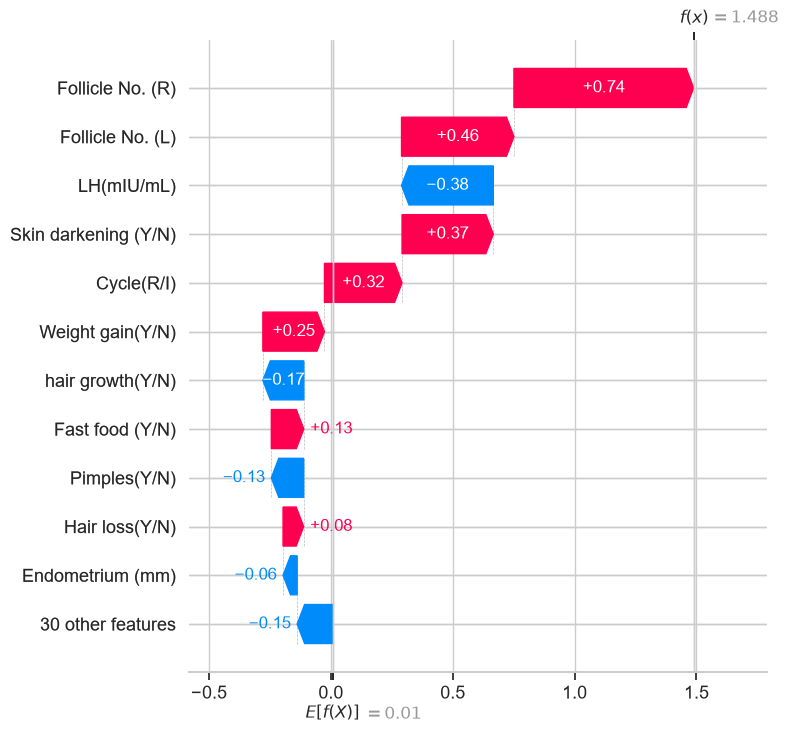

In [116]:
# Pega um paciente do teste que o modelo previu como PCOS positivo
idx_pos = np.where(y_pred_tunado == 1)[0]
i = idx_pos[0] if len(idx_pos) else 0   # primeiro positivo (ou o 0 se não houver)

# base value (valor esperado) - compatível entre versões
ev = explainer.expected_value
base = ev[1] if isinstance(ev, (list, np.ndarray)) and np.ndim(ev) > 0 else ev

print(f"Explicando o paciente de índice {i} no teste:")
print(f"  Real: {'PCOS' if y_test.iloc[i]==1 else 'Não PCOS'} | "
      f"Previsto: {'PCOS' if y_pred_tunado[i]==1 else 'Não PCOS'}\n")

# Waterfall plot (versão moderna do force plot, funciona bem em notebook)
try:
    shap.plots._waterfall.waterfall_legacy(
        base, np.array(shap_pcos)[i], feature_names=list(X.columns), max_display=12, show=False)
    plt.tight_layout()
    plt.show()
except Exception as e:
    print("Waterfall indisponível nesta versão; mostrando contribuições em tabela:", e)
    contrib = pd.Series(np.array(shap_pcos)[i], index=X.columns).sort_values(key=abs, ascending=False)
    print(contrib.head(12))

**📊 Interpretação:** as barras/valores mostram o que puxou a predição para cima (PCOS) ou
para baixo naquele paciente específico. Features com maior contribuição são as "razões" da
decisão. É assim que se traz **transparência** a um modelo de apoio ao diagnóstico.


## 12. Salvar o Modelo Final

**Pergunta:** "Como reaproveitar o modelo sem treinar tudo de novo?"

**Raciocínio:** treinar toda vez é desperdício. Salvamos o **pipeline completo** (scaler +
modelo) com `joblib`. Salvar o pipeline inteiro — e não só o modelo — garante que os dados
novos passarão exatamente pelo mesmo pré-processamento.


In [117]:
import joblib

joblib.dump(modelo_final, "modelo_pcos_final.pkl")
print("✅ Modelo salvo em 'modelo_pcos_final.pkl'")

# Teste rápido: recarrega e confirma que funciona
modelo_carregado = joblib.load("modelo_pcos_final.pkl")
print("✅ Recarregado. Acurácia no teste:",
      round(accuracy_score(y_test, modelo_carregado.predict(X_test)), 3))

✅ Modelo salvo em 'modelo_pcos_final.pkl'
✅ Recarregado. Acurácia no teste: 0.917


## 13. Prever uma Nova Paciente (Exemplo de Uso)

**Pergunta:** "Como usar o modelo na prática, com dados de uma paciente nova?"

**Raciocínio:** simulamos uma "nova paciente" reaproveitando uma linha do teste (assim
garantimos que todas as 42 features estão no formato certo). Numa aplicação real, esses valores
viriam de um formulário/exame. O pipeline cuida do escalonamento automaticamente.


In [118]:
# Simula uma nova paciente pegando uma linha do teste (com todas as features corretas)
nova_paciente = X_test.iloc[[0]].copy()

# O pipeline aplica o scaler e o modelo automaticamente
predicao = modelo_carregado.predict(nova_paciente)[0]
probabilidade = modelo_carregado.predict_proba(nova_paciente)[0, 1]

print("Resultado para a nova paciente:")
print(f"   Predição: {'PCOS DETECTADO (1)' if predicao==1 else 'Sem indício de PCOS (0)'}")
print(f"   Probabilidade de PCOS: {probabilidade*100:.1f}%")
print(f"\n   (Valor real para conferência: "
      f"{'PCOS' if y_test.iloc[0]==1 else 'Não PCOS'})")

Resultado para a nova paciente:
   Predição: Sem indício de PCOS (0)
   Probabilidade de PCOS: 16.6%

   (Valor real para conferência: PCOS)


**Interpretação:** o modelo retorna a **classe** (0/1) e a **probabilidade**. A
probabilidade é útil clinicamente: 51% é bem diferente de 98% de confiança, mesmo que ambos
resultem em "PCOS". Num sistema de apoio à decisão, esse número ajuda o médico a priorizar
casos e pedir exames confirmatórios.

> **Lembrete ético:** este é um modelo de **apoio**, não substitui o diagnóstico médico.
> Ele serve para triagem e priorização, sempre com um profissional na decisão final.
